# YSSY Wind Forecast Pipeline

End-to-end workflow for Sydney Airport (YSSY) wind forecasting:

```
Raw station .txt files (10 stations, half-hourly)
        |
        v
Part 1: Data Cleaning & Parquet
    1. Load 10 station files
    2. Linear interpolation (single-step NaN gaps)
    3. Wind speed/direction -> U/V components
    4. Spline interpolation (gaps up to 5 steps)
    5. Merge stations + save as Parquet
        |
        v
Part 2: Model Training
    1. Load Parquet
    2. Feature engineering (lag features + target construction)
    3. Train/Val/Test split (by time)
    4. Train MultiOutput LightGBM model (96 targets)
    5. Evaluate (MAE/MSE)
        |
        v
Part 3: Visual Display
    1. Forecast vs actual wind plots
    2. Performance vs lead time plot
```

In [1]:
import pandas as pd
import numpy as np
import os, glob, time, warnings
from pathlib import Path
from datetime import timedelta
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy.interpolate import UnivariateSpline
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


In [2]:
# ============================================================
# Configuration
# ============================================================

# --- Paths ---
SCRIPT_DIR = Path.cwd()  # notebook's running directory
RAW_DATA_DIR = SCRIPT_DIR / "../scripts/YSSY-code/data/origional"
PARQUET_DIR = RAW_DATA_DIR.parent  # ../scripts/YSSY-code/data
PARQUET_PATH = PARQUET_DIR / "yssy_cleaned.parquet"

# --- Station list ---
STATION_IDS = ['BELL', 'MTB', 'YBTI', 'YCNK', 'YSBK', 'YSCN', 'YSNW', 'YSRI', 'YSSY', 'YSWG']
TARGET_STATION = 'YSSY'

# --- Interpolation ---
LINEAR_INTERP_COLS = ['air_temp', 'dew_point', 'wind_speed', 'wind_dir', 'msl_pressure']
SPLINE_INTERP_COLS = ['air_temp', 'dew_point', 'msl_pressure', 'u_component', 'v_component']
MAX_GAP = 5        # maximum NaN gap length for spline interpolation
CONTEXT = 6         # points to use on each side of a gap
SPLINE_K = 3        # cubic spline
SPLINE_S = 1        # smoothing factor

# --- Model ---
N_LAGS = 12          # past 6 hours of observations (12 x 30min)
N_STEPS = 48         # forecast 24 hours ahead (48 x 30min)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'
SUBSAMPLE_FRAC = 0.2 # fraction of training data to use (adjust for speed)

LGBM_PARAMS = {
    'n_estimators': 400,
    'learning_rate': 0.05,
    'num_leaves': 100,
    'max_depth': 10,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}
EARLY_STOPPING_ROUNDS = 30

# --- Plotting ---
N_SAMPLE_PLOTS = 4

OUTPUT_DIR = SCRIPT_DIR / "../outputs/yssy_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

PARQUET_DIR.mkdir(parents=True, exist_ok=True)
print(f"Config loaded. Raw data: {RAW_DATA_DIR.resolve()}")
print(f"Parquet output: {PARQUET_PATH.resolve()}")

Output directory: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/outputs/yssy_pipeline
Config loaded. Raw data: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/scripts/YSSY-code/data/origional
Parquet output: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/scripts/YSSY-code/data/yssy_cleaned.parquet


---
# Part 1: Data Cleaning & Parquet

Processes raw station `.txt` files through a three-stage interpolation pipeline, then merges all stations on common timestamps and saves as a single `.parquet` file.

In [3]:
# --- Helper functions ---

def linear_interp_single_step(series):
    """Fill single-step NaN gaps with (prev + next) / 2."""
    result = series.copy()
    is_na = series.isna()
    n = len(series)
    for i in range(1, n - 1):
        if not is_na.iloc[i - 1] and is_na.iloc[i] and not is_na.iloc[i + 1]:
            result.iloc[i] = (series.iloc[i - 1] + series.iloc[i + 1]) / 2.0
    return result


def convert_wind_to_uv(df):
    """Convert wind_speed + wind_dir to u_component + v_component.
    Meteorological convention: u = -speed * sin(dir), v = speed * cos(dir).
    Drops the original wind_speed and wind_dir columns."""
    if 'wind_speed' not in df.columns or 'wind_dir' not in df.columns:
        return df
    ws = pd.to_numeric(df['wind_speed'], errors='coerce')
    wd = pd.to_numeric(df['wind_dir'], errors='coerce')
    dir_rad = np.deg2rad(wd.astype(float))
    df['u_component'] = -ws * np.sin(dir_rad)
    df['v_component'] = ws * np.cos(dir_rad)
    nan_mask = ws.isna() | wd.isna()
    df.loc[nan_mask, ['u_component', 'v_component']] = np.nan
    df.drop(columns=['wind_speed', 'wind_dir'], inplace=True)
    return df


def spline_interp_gap(series, gap_start, gap_end, ctx, k, s):
    """Interpolate a single NaN gap using cubic spline on surrounding context."""
    n = len(series)
    x_known, y_known = [], []
    for (lo, hi) in [(max(0, gap_start - ctx), gap_start - 1),
                      (gap_end + 1, min(n - 1, gap_end + ctx))]:
        if hi >= lo:
            chunk = series.iloc[lo:hi + 1].dropna()
            if not chunk.empty:
                x_known.extend([series.index.get_loc(i) for i in chunk.index])
                y_known.extend(chunk.tolist())
    if len(x_known) < k + 1:
        return None
    x_arr, y_arr = np.array(x_known), np.array(y_known)
    order = np.argsort(x_arr)
    ux, ui = np.unique(x_arr[order], return_index=True)
    if len(ux) < k + 1:
        return None
    try:
        sp = UnivariateSpline(ux, y_arr[order][ui], k=k, s=s)
        ilocs = np.arange(gap_start, gap_end + 1)
        return pd.Series(sp(ilocs), index=series.index[ilocs])
    except Exception:
        return None


def spline_interp_series(series):
    """Apply cubic spline interpolation to all NaN gaps up to MAX_GAP length."""
    result = series.copy()
    is_na = series.isna()
    gap_start = -1
    for i in range(len(series)):
        if is_na.iloc[i] and gap_start == -1:
            gap_start = i
        elif (not is_na.iloc[i] or i == len(series) - 1) and gap_start != -1:
            gap_end = (i - 1) if not is_na.iloc[i] else i
            gap_len = gap_end - gap_start + 1
            if 0 < gap_len <= MAX_GAP:
                vals = spline_interp_gap(series, gap_start, gap_end, CONTEXT, SPLINE_K, SPLINE_S)
                if vals is not None and not vals.empty:
                    result.loc[vals.index] = vals.values
            gap_start = -1
    return result


print("All helper functions defined.")

All helper functions defined.


In [4]:
# --- Process all stations ---

cleaned = {}
total_start = time.time()

for sid in STATION_IDS:
    filepath = RAW_DATA_DIR / f"{sid}.txt"
    if not filepath.exists():
        print(f"  {sid}: file not found, skipping.")
        continue

    t0 = time.time()
    print(f"\n--- {sid} ---")
    df = pd.read_csv(filepath, parse_dates=['timestamp'], na_values=['NaN'])
    print(f"  Loaded {len(df):,} rows")

    # 1. Linear interpolation
    for col in LINEAR_INTERP_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = linear_interp_single_step(df[col])
    print(f"  Linear interp done")

    # 2. Wind -> U/V conversion
    df = convert_wind_to_uv(df)
    print(f"  UV conversion done")

    # 3. Spline interpolation
    df = df.set_index('timestamp')
    for col in SPLINE_INTERP_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = spline_interp_series(df[col])
    df = df.reset_index()
    print(f"  Spline interp done")

    cleaned[sid] = df
    print(f"  Done in {time.time() - t0:.1f}s. Columns: {list(df.columns)}")

print(f"\n=== All stations processed in {time.time() - total_start:.1f}s ===")
print(f"Stations processed: {list(cleaned.keys())}")


--- BELL ---
  Loaded 638,305 rows
  Linear interp done
  UV conversion done
  Spline interp done
  Done in 17.3s. Columns: ['timestamp', 'air_temp', 'dew_point', 'msl_pressure', 'data_completeness', 'u_component', 'v_component']

--- MTB ---
  Loaded 625,509 rows
  Linear interp done
  UV conversion done
  Spline interp done
  Done in 22.4s. Columns: ['timestamp', 'air_temp', 'dew_point', 'msl_pressure', 'data_completeness', 'u_component', 'v_component']

--- YBTI ---
  Loaded 638,305 rows
  Linear interp done
  UV conversion done
  Spline interp done
  Done in 24.8s. Columns: ['timestamp', 'air_temp', 'dew_point', 'msl_pressure', 'data_completeness', 'u_component', 'v_component']

--- YCNK ---
  Loaded 542,143 rows
  Linear interp done
  UV conversion done
  Spline interp done
  Done in 19.9s. Columns: ['timestamp', 'air_temp', 'dew_point', 'msl_pressure', 'data_completeness', 'u_component', 'v_component']

--- YSBK ---
  Loaded 638,303 rows
  Linear interp done
  UV conversion done

Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/01_cleaning_comparison.png


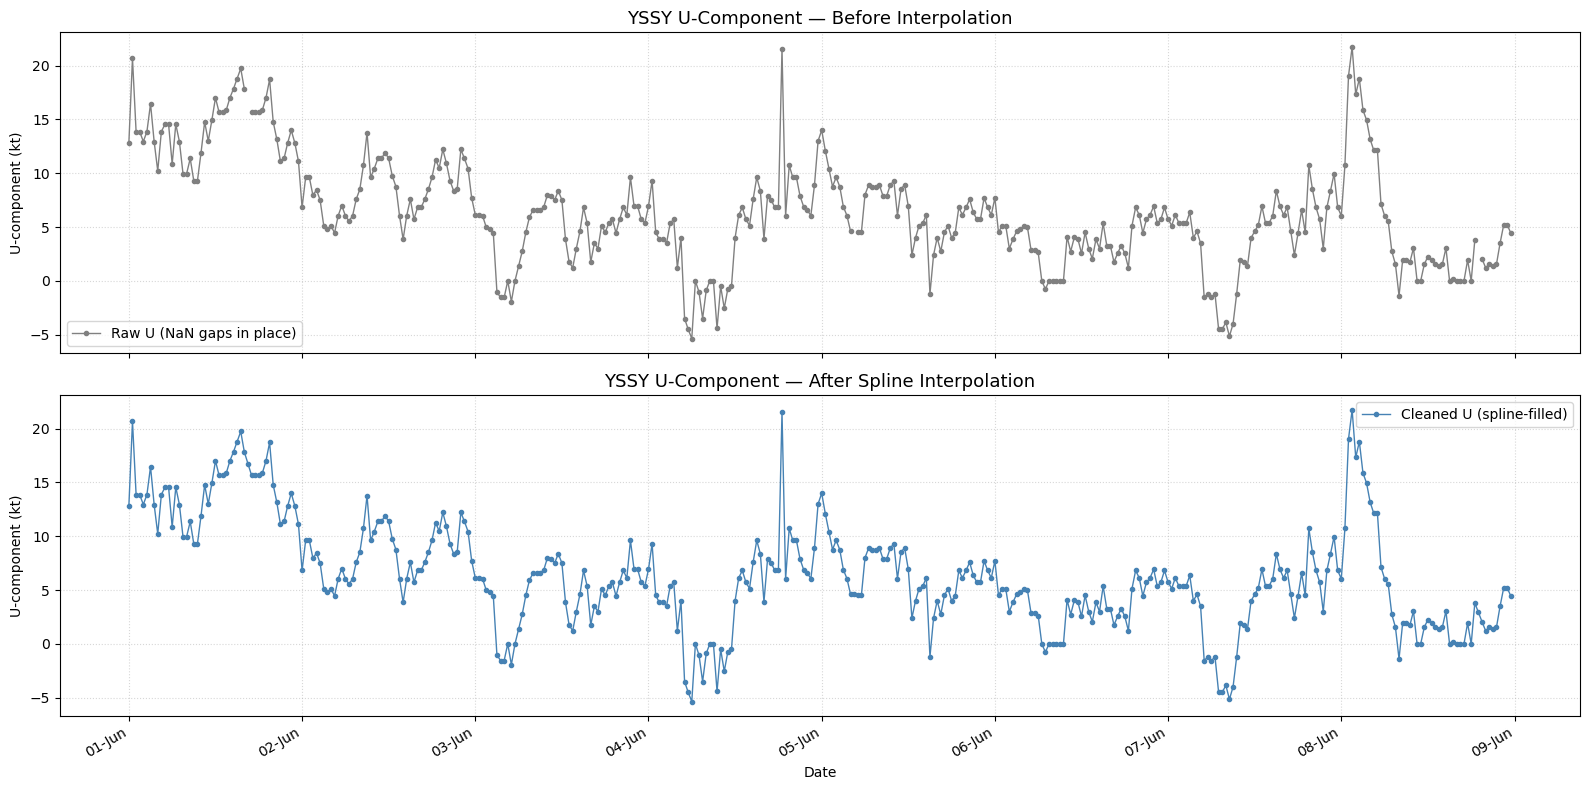

In [5]:
# ----------------------------------------------------------
# Fig 1: Raw vs Cleaned Data — YSSY u_component, one week
# Shows NaN gaps before interpolation vs spline-filled gaps after.
# ----------------------------------------------------------

yssy_raw = pd.read_csv(RAW_DATA_DIR / 'YSSY.txt', parse_dates=['timestamp'], na_values=['NaN'])
yssy_raw = yssy_raw.set_index('timestamp')

# Pick a week with some gaps
week_start = '2015-06-01'
week_end   = '2015-06-08'

raw_slice  = yssy_raw.loc[week_start:week_end].copy()
clean_slice = cleaned['YSSY'].set_index('timestamp').loc[week_start:week_end].copy()

if not raw_slice.empty and not clean_slice.empty:
    ws_raw = pd.to_numeric(raw_slice['wind_speed'], errors='coerce')
    wd_raw = pd.to_numeric(raw_slice['wind_dir'], errors='coerce')
    dir_rad_raw = np.deg2rad(wd_raw.astype(float))
    raw_u = -ws_raw * np.sin(dir_rad_raw)
    clean_u = clean_slice['u_component']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    ax1.plot(raw_u.index, raw_u.values, 'o-', color='gray', markersize=3, linewidth=1, label='Raw U (NaN gaps in place)')
    ax1.set_ylabel('U-component (kt)'); ax1.set_title('YSSY U-Component — Before Interpolation', fontsize=13)
    ax1.grid(True, ls=':', alpha=0.5); ax1.legend()

    ax2.plot(clean_u.index, clean_u.values, 'o-', color='steelblue', markersize=3, linewidth=1, label='Cleaned U (spline-filled)')
    ax2.set_ylabel('U-component (kt)'); ax2.set_title('YSSY U-Component — After Spline Interpolation', fontsize=13)
    ax2.set_xlabel('Date'); ax2.grid(True, ls=':', alpha=0.5); ax2.legend()

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '01_cleaning_comparison.png', dpi=150)
    print(f'Saved: {OUTPUT_DIR / "01_cleaning_comparison.png"}')
    plt.show()
else:
    print('  Not enough data for cleaning comparison plot.')


In [6]:
# --- Merge all stations on timestamp ---

t0 = time.time()
dfs = []
for sid, df in cleaned.items():
    df = df.set_index('timestamp')
    # Prefix all columns with station ID
    df.columns = [f"{sid}_{c}" for c in df.columns]
    dfs.append(df)

merged = pd.concat(dfs, axis=1)
merged = merged.sort_index()
merged = merged.reset_index()  # timestamp becomes a column

n_cols = len(merged.columns)
n_rows = len(merged)
print(f"Merged: {n_rows:,} rows x {n_cols} columns")
print(f"Time range: {merged['timestamp'].min()} to {merged['timestamp'].max()}")
print(f"Merge took {time.time() - t0:.1f}s")

Merged: 796,090 rows x 63 columns
Time range: 1980-01-02 00:30:00 to 2025-05-30 05:00:00
Merge took 0.4s


Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/02_station_coverage.png


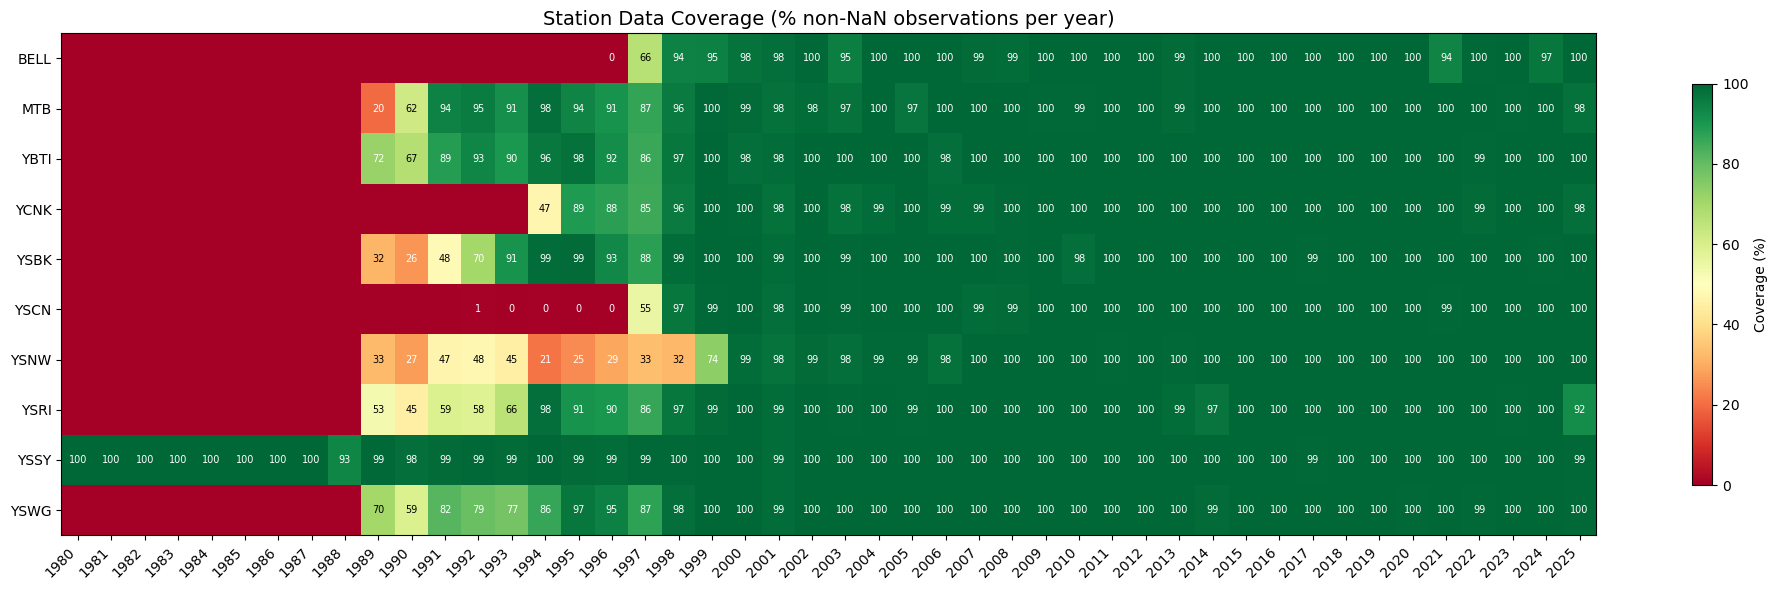

In [7]:
# ----------------------------------------------------------
# Fig 2: Station Data Coverage — non-NaN % per station per year
# ----------------------------------------------------------

if 'merged' in dir() and merged is not None:
    m = merged.set_index('timestamp').copy()
    coverage_rows = []
    for sid in STATION_IDS:
        # Pick a representative column per station
        rep_col = f'{sid}_air_temp' if f'{sid}_air_temp' in m.columns else None
        if rep_col is None:
            # fallback: find any column for this station
            matches = [c for c in m.columns if c.startswith(f'{sid}_')]
            rep_col = matches[0] if matches else None
        if rep_col is None:
            continue
        for year in range(m.index.year.min(), m.index.year.max() + 1):
            yr_data = m.loc[str(year), rep_col] if str(year) in [str(y) for y in m.index.year.unique()] else pd.Series(dtype=float)
            if len(yr_data) == 0:
                pct = 0
            else:
                pct = yr_data.notna().sum() / len(yr_data) * 100
            coverage_rows.append({'station': sid, 'year': year, 'coverage_pct': pct})

    cov_df = pd.DataFrame(coverage_rows)
    if not cov_df.empty:
        pivot = cov_df.pivot(index='station', columns='year', values='coverage_pct')
        # Keep only columns with > 0 coverage in at least one station
        pivot = pivot.loc[:, (pivot > 0).any()]

        fig, ax = plt.subplots(figsize=(20, 6))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_title('Station Data Coverage (% non-NaN observations per year)', fontsize=14)
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label('Coverage (%)')
        # Annotate cells
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if val > 0:
                    ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7,
                            color='black' if 30 < val < 70 else 'white')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / '02_station_coverage.png', dpi=150)
        print(f'Saved: {OUTPUT_DIR / "02_station_coverage.png"}')
        plt.show()
    else:
        print('  Not enough data for coverage plot.')
else:
    print('  merged DataFrame not found. Run merge cell first.')


In [8]:
# --- Save as Parquet ---

t0 = time.time()
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
merged.to_parquet(PARQUET_PATH, index=False)
size_mb = os.path.getsize(PARQUET_PATH) / 1e6
print(f"Saved: {PARQUET_PATH}")
print(f"Size: {size_mb:.1f} MB")
print(f"Done in {time.time() - t0:.1f}s")

Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../scripts/YSSY-code/data/yssy_cleaned.parquet
Size: 53.7 MB
Done in 0.5s


---
# Part 2: Model Training

Loads the cleaned Parquet file, constructs lag features and forecast targets, then trains a **MultiOutput LightGBM model** to predict YSSY wind U/V components 0.5 to 24 hours ahead (48 half-hourly steps x 2 components = **96 targets**).

In [9]:
# --- Load Parquet ---

t0 = time.time()
df = pd.read_parquet(PARQUET_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Done in {time.time() - t0:.1f}s")

Loaded: 796,090 rows x 62 columns
Time range: 1980-01-02 00:30:00 to 2025-05-30 05:00:00
Done in 0.2s


In [10]:
# --- Feature Engineering ---

t0 = time.time()

# 1. YSSY U/V lag features (past 6 hours)
for lag in range(N_LAGS):
    df[f'yssy_u_lag{lag}'] = df[f'{TARGET_STATION}_u_component'].shift(lag)
    df[f'yssy_v_lag{lag}'] = df[f'{TARGET_STATION}_v_component'].shift(lag)
print(f"Lag features created: {N_LAGS * 2} columns")

# 2. Target columns (future 24 hours of YSSY U/V)
target_cols = []
for step in range(1, N_STEPS + 1):
    u_col = f'target_u_t{step}'
    v_col = f'target_v_t{step}'
    df[u_col] = df[f'{TARGET_STATION}_u_component'].shift(-step)
    df[v_col] = df[f'{TARGET_STATION}_v_component'].shift(-step)
    target_cols.extend([u_col, v_col])
print(f"Target columns created: {len(target_cols)}")

# 3. Drop rows where any target is NaN (end of dataset, insufficient future data)
before_drop = len(df)
df = df.dropna(subset=target_cols)
print(f"Rows after dropping incomplete targets: {len(df):,} (dropped {before_drop - len(df):,})")

# 4. Build feature set: YSSY lag features + other stations' current observations
feature_cols = [f'yssy_u_lag{lag}' for lag in range(N_LAGS)] + \
              [f'yssy_v_lag{lag}' for lag in range(N_LAGS)]

other_vars = ['air_temp', 'dew_point', 'msl_pressure', 'u_component', 'v_component']
for sid in STATION_IDS:
    if sid == TARGET_STATION:
        continue
    for var in other_vars:
        col = f'{sid}_{var}'
        if col in df.columns:
            feature_cols.append(col)

print(f"Total features: {len(feature_cols)}")
print(f"Done in {time.time() - t0:.1f}s")

Lag features created: 24 columns
Target columns created: 96
Rows after dropping incomplete targets: 789,441 (dropped 6,649)
Total features: 69
Done in 0.4s


Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/03_feature_engineering.png


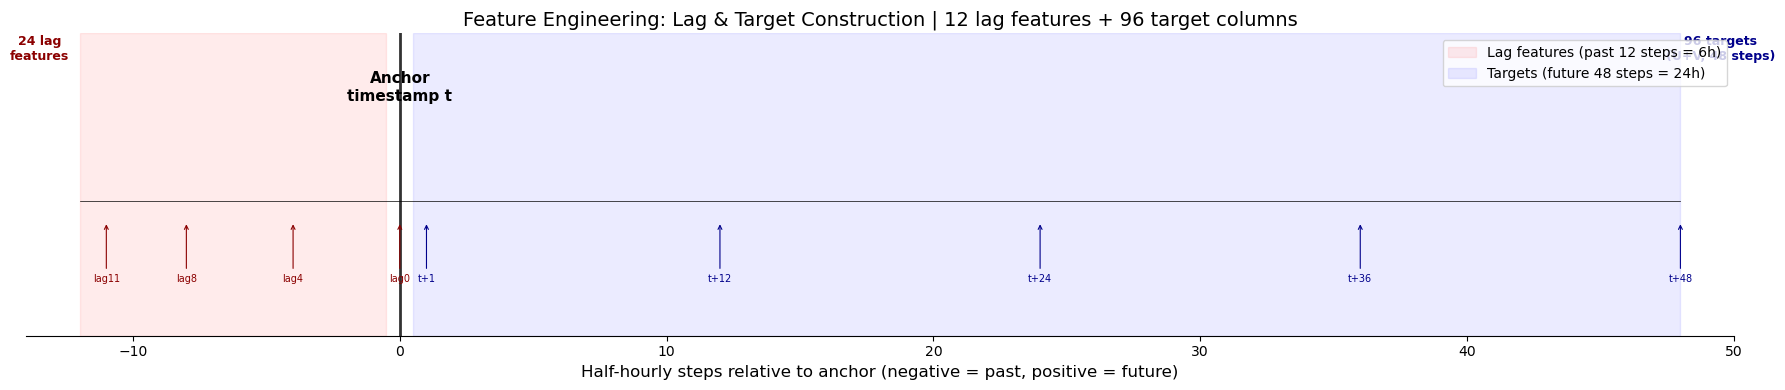

In [11]:
# ----------------------------------------------------------
# Fig 3: Feature-Target Construction Diagram
# Shows how lag features (past) and target columns (future) are built
# relative to the anchor timestamp t.
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(18, 4))

# Time axis
steps = np.arange(-12, N_STEPS + 1, 4)
ax.plot([-12, N_STEPS], [0, 0], 'k-', linewidth=0.5)

# Anchor point
ax.axvline(0, color='black', linewidth=2, linestyle='-', alpha=0.8)
ax.text(0, 1.5, 'Anchor\ntimestamp t', ha='center', fontsize=11, fontweight='bold')

# Lag region (past, red)
ax.axvspan(-N_LAGS, -0.5, alpha=0.08, color='red', label=f'Lag features (past {N_LAGS} steps = 6h)')
for lag in [0, 4, 8, 11]:
    ax.annotate(f'lag{lag}', xy=(-lag, -0.3), ha='center', fontsize=7, color='darkred',
                xytext=(-lag, -1.2), arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

# Target region (future, blue)
ax.axvspan(0.5, N_STEPS, alpha=0.08, color='blue', label=f'Targets (future {N_STEPS} steps = 24h)')
for step in [1, 12, 24, 36, 48]:
    ax.annotate(f't+{step}', xy=(step, -0.3), ha='center', fontsize=7, color='darkblue',
                xytext=(step, -1.2), arrowprops=dict(arrowstyle='->', color='darkblue', lw=0.8))

ax.set_xlim(-N_LAGS - 2, N_STEPS + 2)
ax.set_ylim(-2, 2.5)
ax.set_xlabel('Half-hourly steps relative to anchor (negative = past, positive = future)', fontsize=12)
ax.set_yticks([])
ax.spines[['left', 'right', 'top']].set_visible(False)
ax.set_title(f'Feature Engineering: Lag & Target Construction | {N_LAGS} lag features + {N_STEPS*2} target columns', fontsize=14)
ax.legend(loc='upper right', fontsize=10)

# Feature and target count annotation
ax.text(-N_LAGS - 1.5, 2.1, f'{N_LAGS*2} lag\nfeatures', ha='center', fontsize=9, color='darkred', fontweight='bold')
ax.text(N_STEPS + 1.5, 2.1, f'{N_STEPS*2} targets\n(U+V, 48 steps)', ha='center', fontsize=9, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_feature_engineering.png', dpi=150)
print(f'Saved: {OUTPUT_DIR / "03_feature_engineering.png"}')
plt.show()


In [12]:
# --- Train / Validation / Test split (by time) ---

mask_train = df.index <= TRAIN_END
mask_val = (df.index >= VAL_START) & (df.index <= VAL_END)
mask_test = df.index >= TEST_START

X_train, y_train = df.loc[mask_train, feature_cols], df.loc[mask_train, target_cols]
X_val, y_val = df.loc[mask_val, feature_cols], df.loc[mask_val, target_cols]
X_test, y_test = df.loc[mask_test, feature_cols], df.loc[mask_test, target_cols]

# Optional subsample for faster training
if SUBSAMPLE_FRAC < 1.0 and len(X_train) > 0:
    X_train = X_train.sample(frac=SUBSAMPLE_FRAC, random_state=42)
    y_train = y_train.loc[X_train.index]

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Features: {X_train.shape[1]} | Targets: {y_train.shape[1]}")

Train: 145,961 | Val: 17,473 | Test: 42,070
Features: 69 | Targets: 96


Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/04_data_split.png


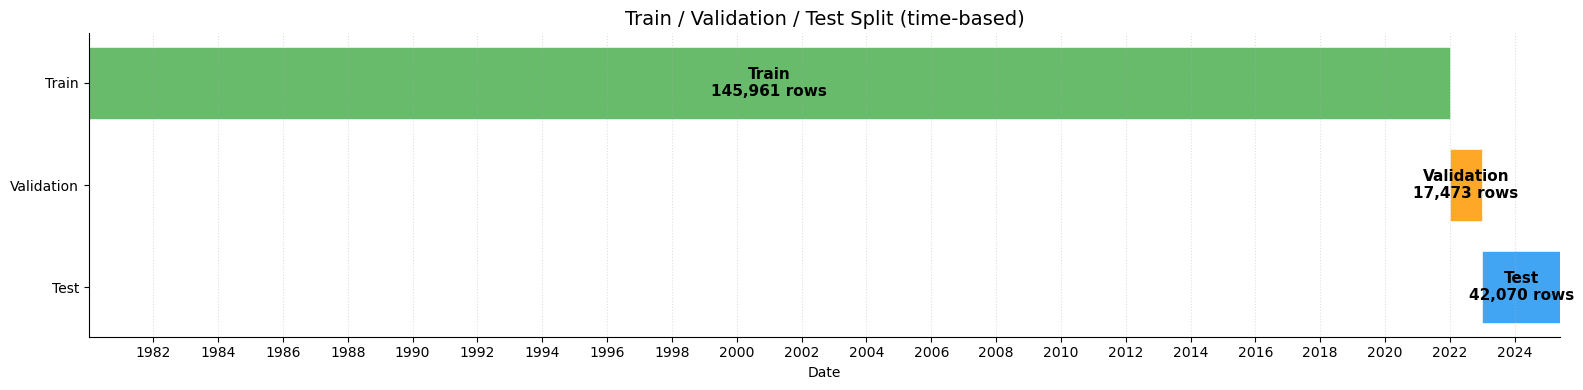

In [13]:
# ----------------------------------------------------------
# Fig 4: Train / Val / Test Split Timeline
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 4))

splits = [
    ('Train', df.index.min(), TRAIN_END, '#4CAF50'),
    ('Validation', VAL_START, VAL_END, '#FF9800'),
    ('Test',     TEST_START, df.index.max(), '#2196F3'),
]

y_positions = [1, 0.5, 0]
for (label, start, end, color), y in zip(splits, y_positions):
    s_dt = pd.Timestamp(start)
    e_dt = pd.Timestamp(end)
    ax.barh(y, (e_dt - s_dt).days, left=mdates.date2num(s_dt),
            height=0.35, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    mid = s_dt + (e_dt - s_dt) / 2
    count = {'Train': len(X_train), 'Validation': len(X_val), 'Test': len(X_test)}[label]
    ax.text(mdates.date2num(mid), y, f'{label}\n{count:,} rows', ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels([s[0] for s in splits])
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlim(mdates.date2num(pd.Timestamp(df.index.min())),
            mdates.date2num(pd.Timestamp(df.index.max())))
ax.set_title('Train / Validation / Test Split (time-based)', fontsize=14)
ax.grid(axis='x', ls=':', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_data_split.png', dpi=150)
print(f'Saved: {OUTPUT_DIR / "04_data_split.png"}')
plt.show()


In [14]:
# --- Train MultiOutput LightGBM Model ---

print(f"Training MultiOutputRegressor with {LGBM_PARAMS['n_estimators']} max estimators...")
base_model = lgb.LGBMRegressor(**LGBM_PARAMS)
model = MultiOutputRegressor(base_model, n_jobs=-1)

t0 = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"Training done in {elapsed:.1f}s ({elapsed/60:.1f} min)")

Training MultiOutputRegressor with 400 max estimators...
Training done in 512.9s (8.5 min)


Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/05_feature_importance.png


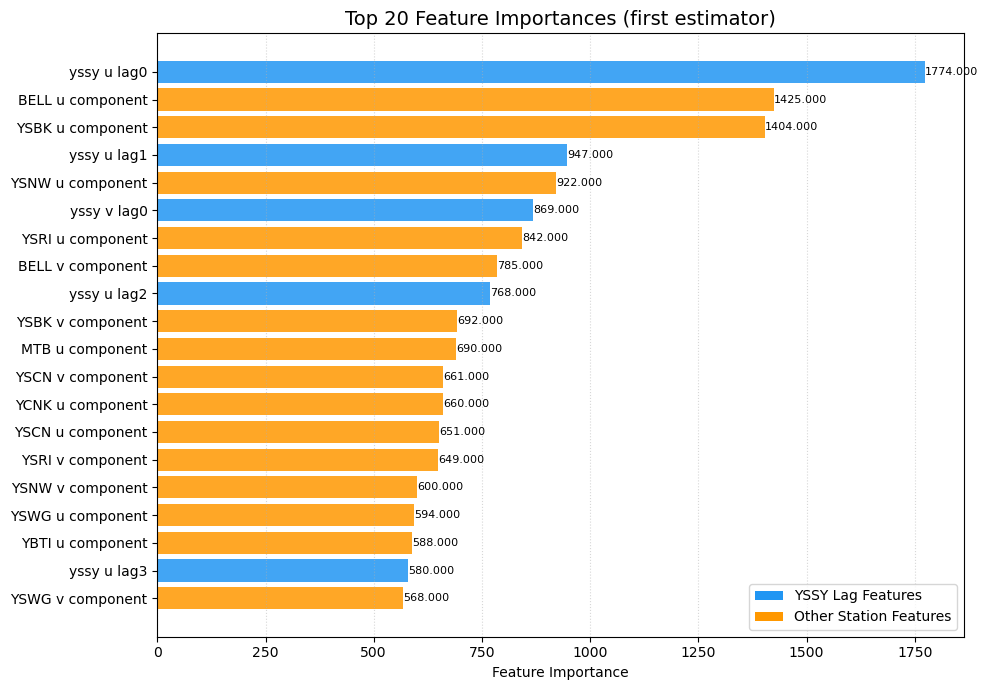

In [15]:
# ----------------------------------------------------------
# Fig 5: Feature Importance — Top 20 features
# Uses the first estimator's feature_importances_ as representative.
# ----------------------------------------------------------

if hasattr(model, 'estimators_') and len(model.estimators_) > 0:
    est = model.estimators_[0]
    imp = est.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': imp})
    fi_df = fi_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#2196F3' if 'lag' in f else '#FF9800' for f in fi_df['feature']]
    bars = ax.barh(range(len(fi_df)), fi_df['importance'].values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(fi_df)))
    ax.set_yticklabels(fi_df['feature'].str.replace('YSSY_', '', regex=False).str.replace('_', ' ', regex=False))
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 20 Feature Importances (first estimator)', fontsize=14)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2196F3', label='YSSY Lag Features'),
                       Patch(facecolor='#FF9800', label='Other Station Features')]
    ax.legend(handles=legend_elements, loc='lower right')
    ax.grid(axis='x', ls=':', alpha=0.5)

    for i, (_, row) in enumerate(fi_df.iterrows()):
        ax.text(row['importance'] + 0.001, i, f"{row['importance']:.3f}", va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '05_feature_importance.png', dpi=150)
    print(f'Saved: {OUTPUT_DIR / "05_feature_importance.png"}')
    plt.show()
else:
    print('  Model not trained yet. Run training cell first.')


In [16]:
# --- Evaluate on Test Set ---

t0 = time.time()
y_pred = model.predict(X_test)

overall_mae = mean_absolute_error(y_test, y_pred)
overall_mse = mean_squared_error(y_test, y_pred)
print(f"Overall Test MAE: {overall_mae:.4f}")
print(f"Overall Test MSE: {overall_mse:.4f}")

# Per-step metrics
rows = []
for step in range(1, N_STEPS + 1):
    u_col, v_col = f'target_u_t{step}', f'target_v_t{step}'
    idx_u, idx_v = target_cols.index(u_col), target_cols.index(v_col)
    mae_u = mean_absolute_error(y_test.iloc[:, idx_u], y_pred[:, idx_u])
    mae_v = mean_absolute_error(y_test.iloc[:, idx_v], y_pred[:, idx_v])
    mse_u = mean_squared_error(y_test.iloc[:, idx_u], y_pred[:, idx_u])
    mse_v = mean_squared_error(y_test.iloc[:, idx_v], y_pred[:, idx_v])
    rows.append({'step': step, 'hours': step * 0.5,
                 'MAE_u': mae_u, 'MAE_v': mae_v, 'Avg_MAE': (mae_u + mae_v) / 2,
                 'MSE_u': mse_u, 'MSE_v': mse_v, 'Avg_MSE': (mse_u + mse_v) / 2})

metrics_df = pd.DataFrame(rows)
print(f"Evaluation done in {time.time() - t0:.1f}s")
display(metrics_df.round(4).head(12))

Overall Test MAE: 4.3502
Overall Test MSE: 34.0735
Evaluation done in 22.9s


,step,hours,MAE_u,MAE_v,Avg_MAE,MSE_u,MSE_v,Avg_MSE
0,1,0.5,1.7239,1.7615,1.7427,6.0322,6.3223,6.1773
1,2,1.0,2.1164,2.1880,2.1522,8.6214,9.2066,8.9140
2,3,1.5,2.3658,2.4638,2.4148,10.5387,11.4355,10.9871
3,4,2.0,2.5570,2.6969,2.6270,12.1002,13.5359,12.8181
4,5,2.5,2.7338,2.8937,2.8138,13.6090,15.4866,14.5478
5,6,3.0,2.9013,3.0750,2.9882,15.0684,17.4260,16.2472
6,7,3.5,3.0648,3.2649,3.1649,16.5510,19.5277,18.0393
7,8,4.0,3.2302,3.4316,3.3309,18.2175,21.5511,19.8843
8,9,4.5,3.3756,3.5826,3.4791,19.6563,23.4441,21.5502
9,10,5.0,3.5227,3.7382,3.6305,21.1594,25.3346,23.2470


Saved: /Users/kechengzhang/Projects/kechengzhang28/BOM-Team/team-members/kecheng-zhang/notebooks/../outputs/yssy_pipeline/06_scatter_pred_actual.png


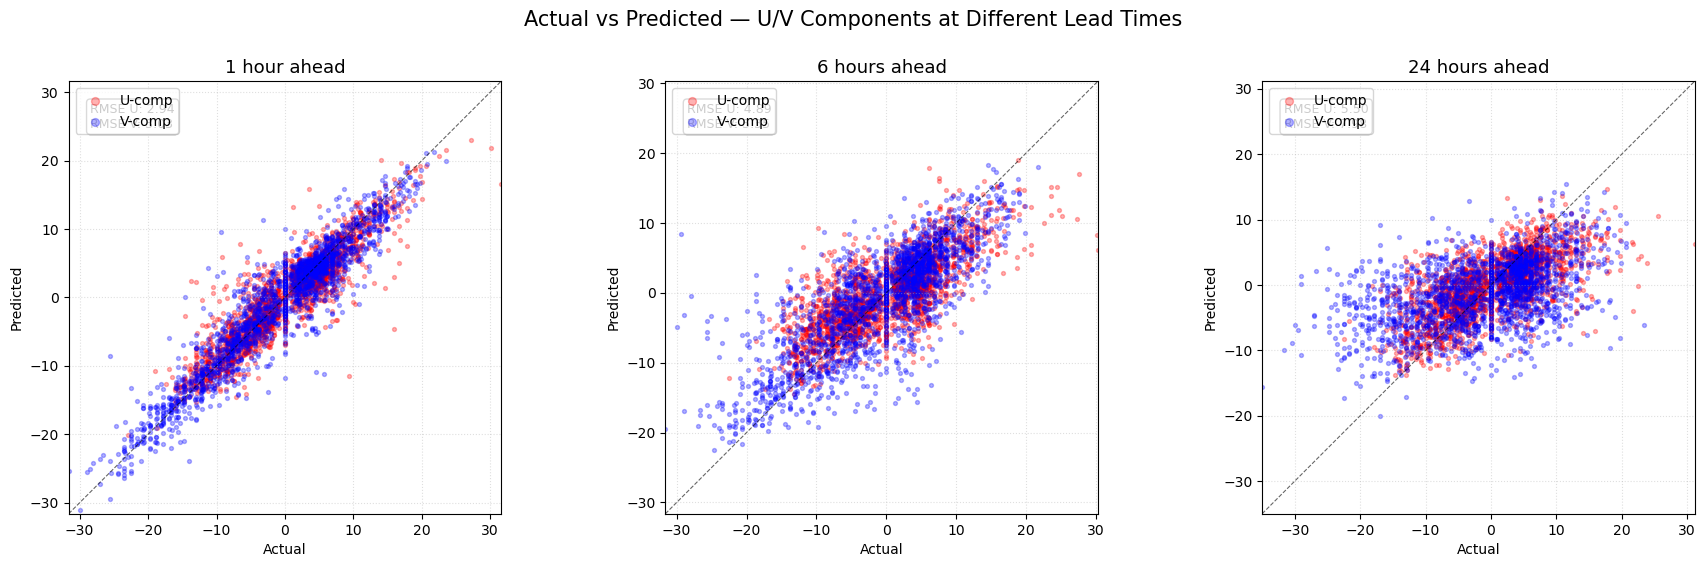

In [17]:
# ----------------------------------------------------------
# Fig 6: Actual vs Predicted — scatter for 3 forecast lead times
# Shows how the model's predictive accuracy degrades with lead time.
# ----------------------------------------------------------

if 'y_pred' in dir() and 'y_test' in dir():
    steps_to_show = [2, 12, 48]  # 1h, 6h, 24h
    titles = ['1 hour ahead', '6 hours ahead', '24 hours ahead']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for ax, step, title_str in zip(axes, steps_to_show, titles):
        u_col = f'target_u_t{step}'
        v_col = f'target_v_t{step}'
        if u_col not in target_cols or v_col not in target_cols:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title_str); continue

        idx_u = target_cols.index(u_col)
        idx_v = target_cols.index(v_col)
        actual_u = y_test.iloc[:, idx_u].values
        pred_u   = y_pred[:, idx_u]
        actual_v = y_test.iloc[:, idx_v].values
        pred_v   = y_pred[:, idx_v]

        # Subsample for scatter clarity
        n_pts = min(2000, len(actual_u))
        sub = np.random.choice(len(actual_u), n_pts, replace=False)

        ax.scatter(actual_u[sub], pred_u[sub], alpha=0.3, s=8, color='red', label='U-comp')
        ax.scatter(actual_v[sub], pred_v[sub], alpha=0.3, s=8, color='blue', label='V-comp')

        all_vals = np.concatenate([actual_u[sub], pred_u[sub], actual_v[sub], pred_v[sub]])
        lo = np.nanmin(all_vals); hi = np.nanmax(all_vals)
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.6)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
        ax.set_title(f'{title_str}', fontsize=13)
        ax.legend(loc='upper left', markerscale=2)
        ax.grid(True, ls=':', alpha=0.4)
        ax.set_aspect('equal')

        # Add RMSE text
        rmse_u = np.sqrt(np.nanmean((actual_u - pred_u)**2))
        rmse_v = np.sqrt(np.nanmean((actual_v - pred_v)**2))
        ax.text(0.05, 0.95, f'RMSE U: {rmse_u:.2f}\nRMSE V: {rmse_v:.2f}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    fig.suptitle('Actual vs Predicted — U/V Components at Different Lead Times', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '06_scatter_pred_actual.png', dpi=150)
    print(f'Saved: {OUTPUT_DIR / "06_scatter_pred_actual.png"}')
    plt.show()
else:
    print('  Predictions not available. Run evaluation cell first.')


---
# Part 3: Visual Display

In [18]:
# --- Helper: U/V -> wind speed & direction ---

def uv_to_ws_wd(u, v):
    """Convert U/V components to wind speed (knots) and direction (degrees)."""
    u, v = np.asarray(u, float), np.asarray(v, float)
    ws = np.sqrt(u**2 + v**2)
    wd = (270 - np.degrees(np.arctan2(-v, u))) % 360
    wd[ws < 0.1] = 0
    return ws, wd


def plot_forecast_sample(idx, X_row, y_true_row, y_pred_row, ts):
    """Plot observed data plus forecasted wind for a single sample."""
    plot_start = ts - timedelta(hours=24)
    plot_end = ts + timedelta(hours=24)

    # Observed data from the cleaned DataFrame (still available from Part 2)
    obs_slice = df.loc[plot_start:plot_end]
    if obs_slice.empty:
        print(f"  No obs data for {ts}")
        return

    obs_t = obs_slice.index
    obs_temp = obs_slice.get(f'{TARGET_STATION}_air_temp', pd.Series(np.nan, index=obs_slice.index)).values
    obs_dewp = obs_slice.get(f'{TARGET_STATION}_dew_point', pd.Series(np.nan, index=obs_slice.index)).values
    obs_u = obs_slice.get(f'{TARGET_STATION}_u_component', pd.Series(np.nan, index=obs_slice.index)).values
    obs_v = obs_slice.get(f'{TARGET_STATION}_v_component', pd.Series(np.nan, index=obs_slice.index)).values
    obs_ws, obs_wd = uv_to_ws_wd(obs_u, obs_v)

    # Forecast future times
    fcst_t = [ts + timedelta(minutes=30 * i) for i in range(1, N_STEPS + 1)]
    fcst_u = y_pred_row[0::2]  # every other element is u
    fcst_v = y_pred_row[1::2]  # every other element is v
    fcst_ws, fcst_wd = uv_to_ws_wd(fcst_u, fcst_v)

    fig, ax1 = plt.subplots(figsize=(18, 9))
    fig.suptitle(f"YSSY Wind Forecast — Anchor: {ts.strftime('%Y-%m-%d %H:%M')}", fontsize=15)

    ax1.plot(obs_t, obs_temp, 'r-', alpha=0.7, label='Obs Temp (C)')
    ax1.plot(obs_t, obs_dewp, 'b-', alpha=0.7, label='Obs Dewpoint (C)')
    ax1.plot(obs_t, obs_ws, '-', color='gray', lw=2.5, alpha=0.7, label='Obs Wind Speed (kt)')
    ax1.plot(fcst_t, fcst_ws, '-', color='black', lw=3.5, label='Fcst Wind Speed')
    ax1.set_ylabel('Temp (C) / Wind Speed (kt)')
    ax1.grid(True, ls=':', alpha=0.5)
    ax1.yaxis.set_major_locator(mticker.MultipleLocator(5))

    # Dynamic Y limit
    all_vals = np.concatenate([obs_temp[~np.isnan(obs_temp)], obs_dewp[~np.isnan(obs_dewp)],
                                obs_ws[~np.isnan(obs_ws)], fcst_ws[~np.isnan(fcst_ws)]])
    y_lo = min(0, np.floor(np.nanmin(all_vals) / 5) * 5) if len(all_vals) > 0 else 0
    y_hi = max(30, np.ceil(np.nanmax(all_vals) / 5) * 5) if len(all_vals) > 0 else 40
    ax1.set_ylim(y_lo, y_hi)

    ax2 = ax1.twinx()
    ax2.scatter(obs_t, obs_wd, marker='o', color='darkgray', s=40, alpha=0.6, label='Obs Wind Dir')
    ax2.scatter(fcst_t, fcst_wd, marker='X', color='black', s=55, label='Fcst Wind Dir')
    ax2.set_ylabel('Wind Direction (deg)')
    ax2.set_ylim(0, 360)
    ax2.yaxis.set_major_locator(mticker.MultipleLocator(45))

    ax1.set_xlim(plot_start, plot_end)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d-%b'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax1.axvline(ts, color='k', ls=':', lw=1, alpha=0.5)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    plt.show()

print("Plotting function defined.")

Plotting function defined.


Plotting 4 random test samples...



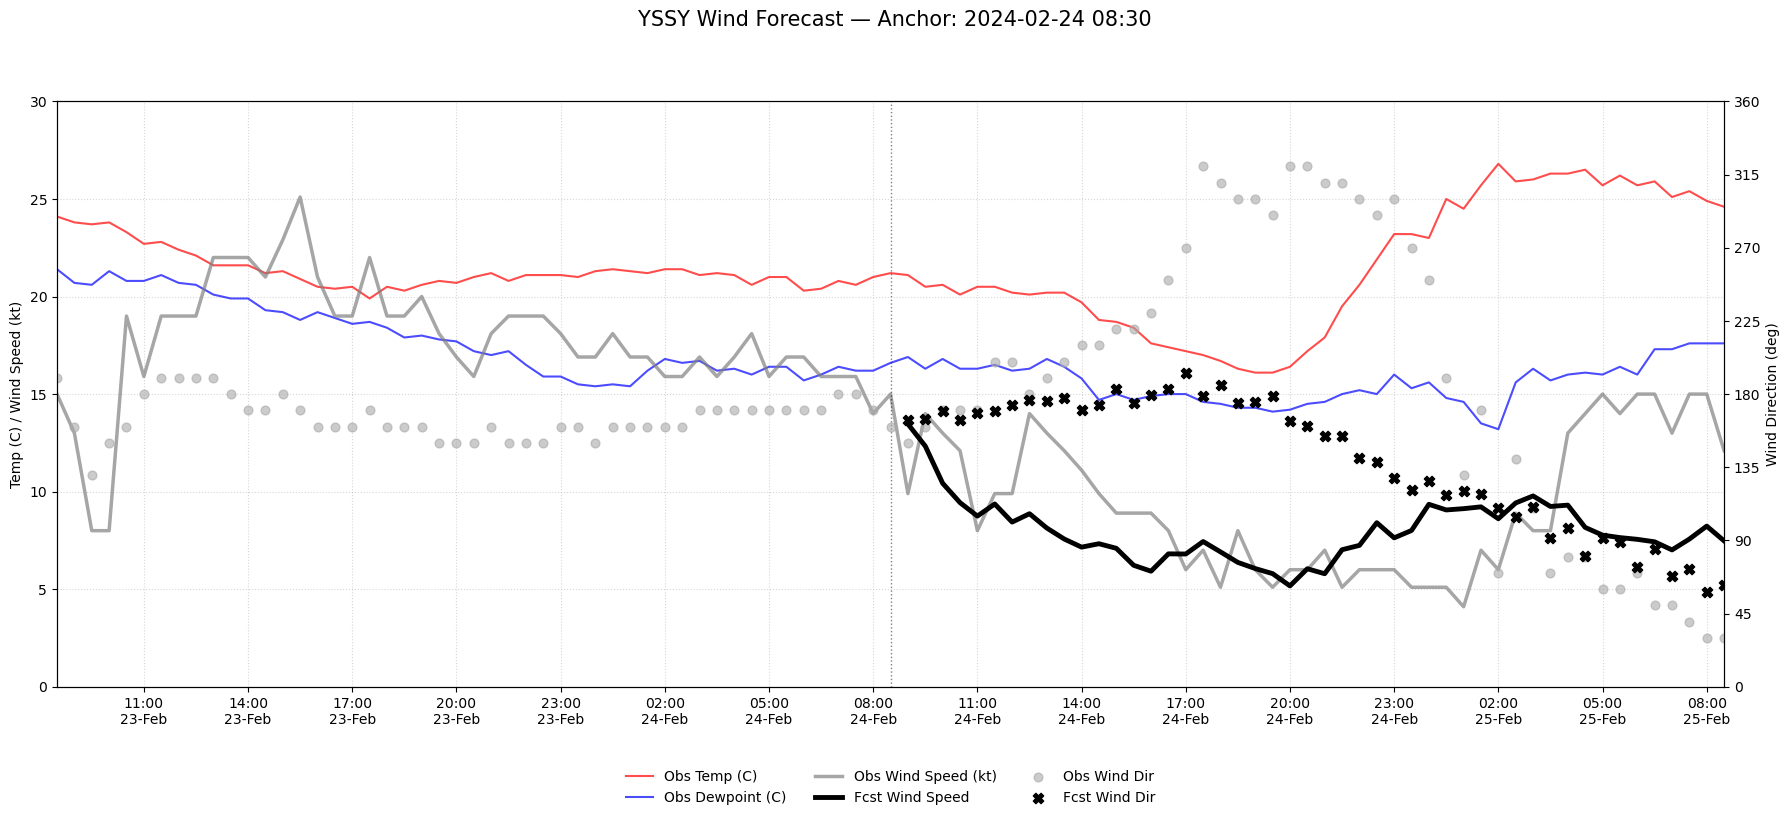

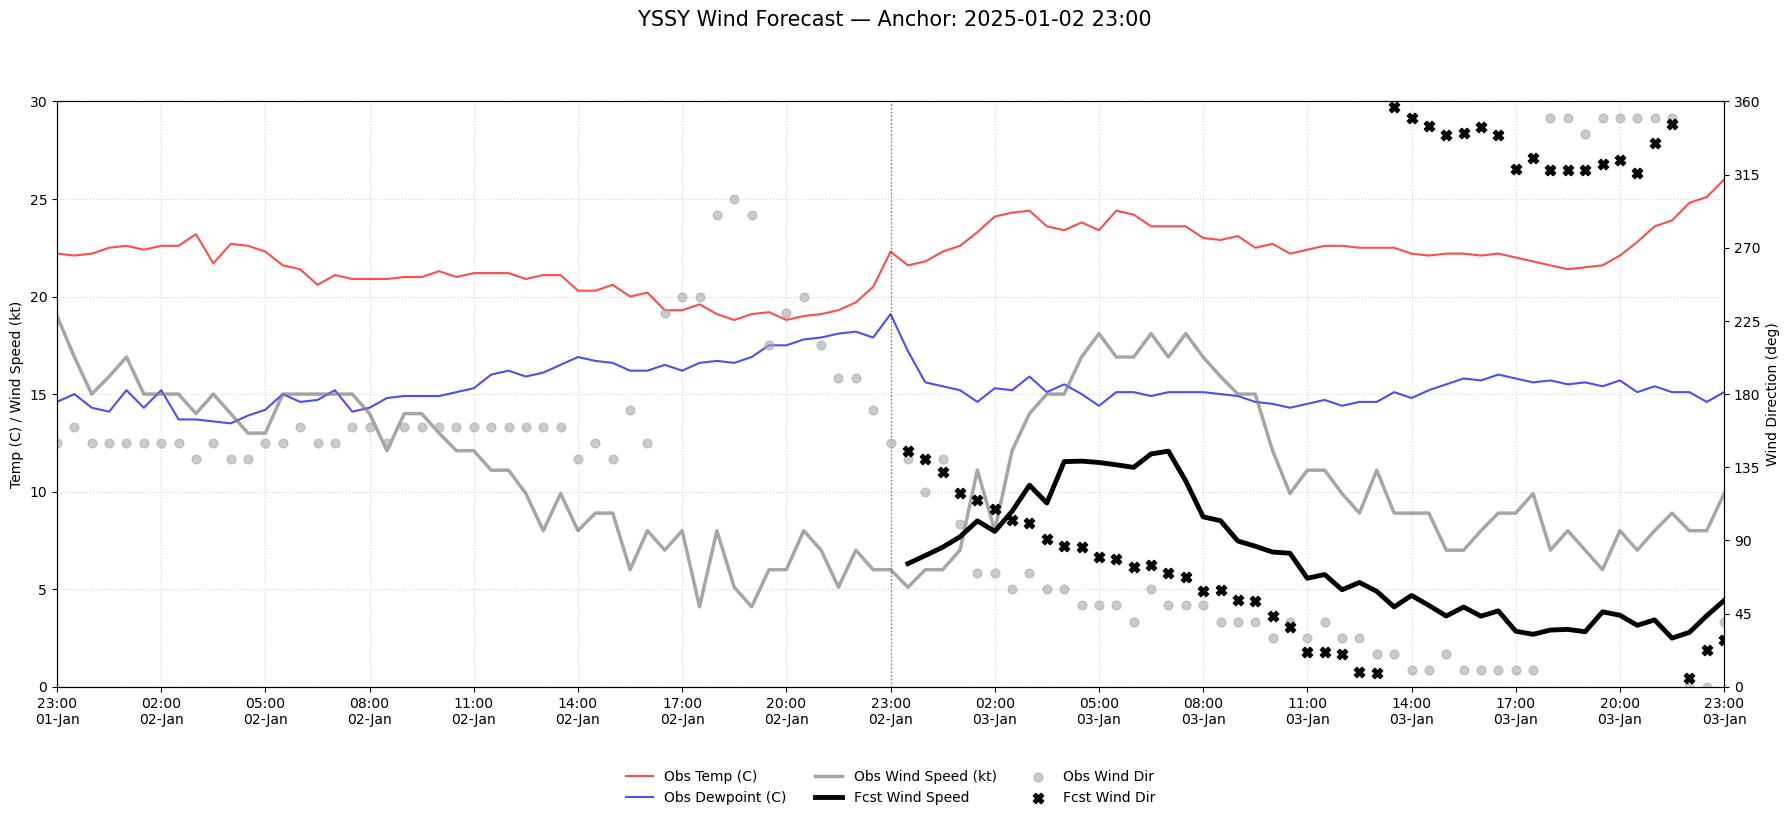

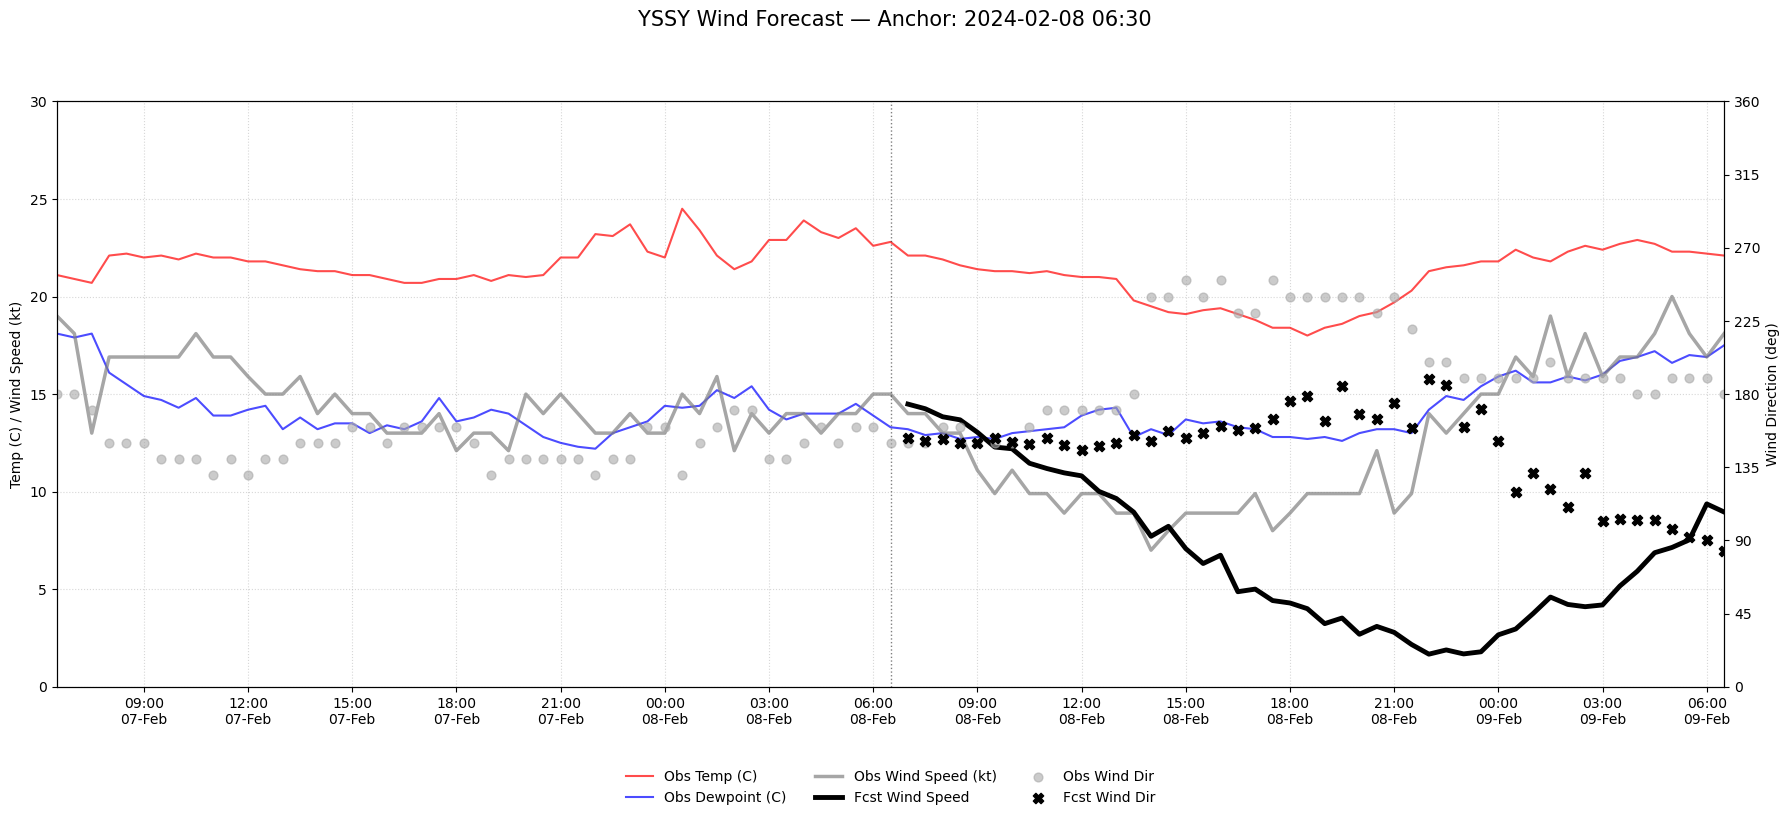

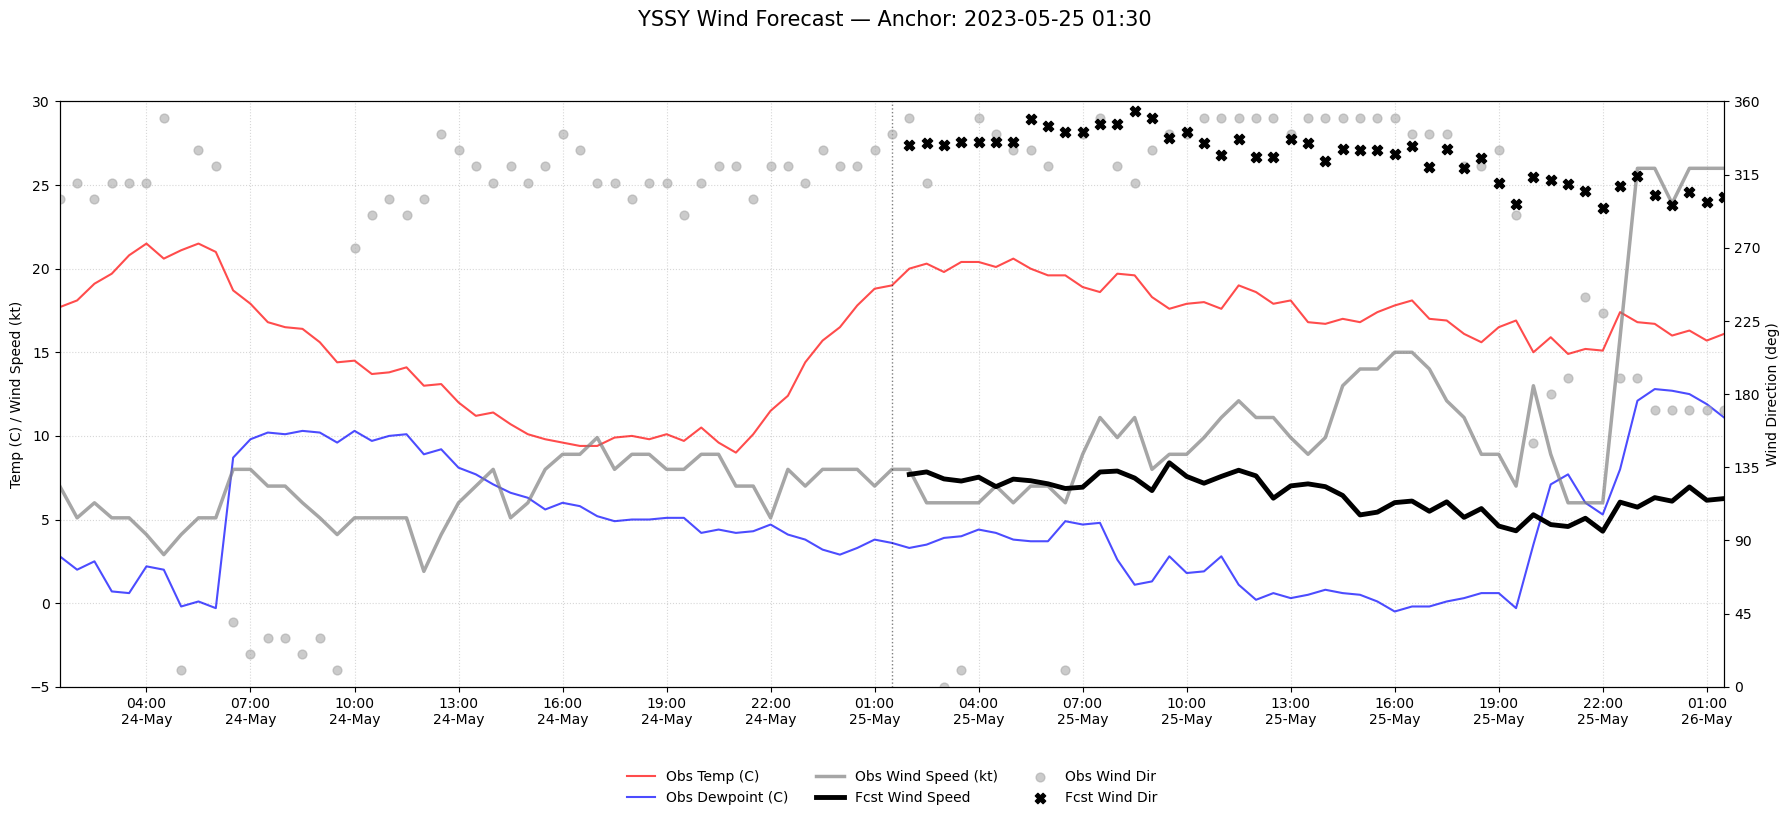

In [19]:
# --- Forecast vs Actual: Random Test Samples ---

np.random.seed(42)
n_plots = min(N_SAMPLE_PLOTS, len(X_test))
sample_idx = np.random.choice(len(X_test), n_plots, replace=False)

print(f"Plotting {n_plots} random test samples...\n")
for i, idx in enumerate(sample_idx):
    ts = X_test.index[idx]
    plot_forecast_sample(idx, X_test.iloc[idx], y_test.iloc[idx], y_pred[idx], ts)

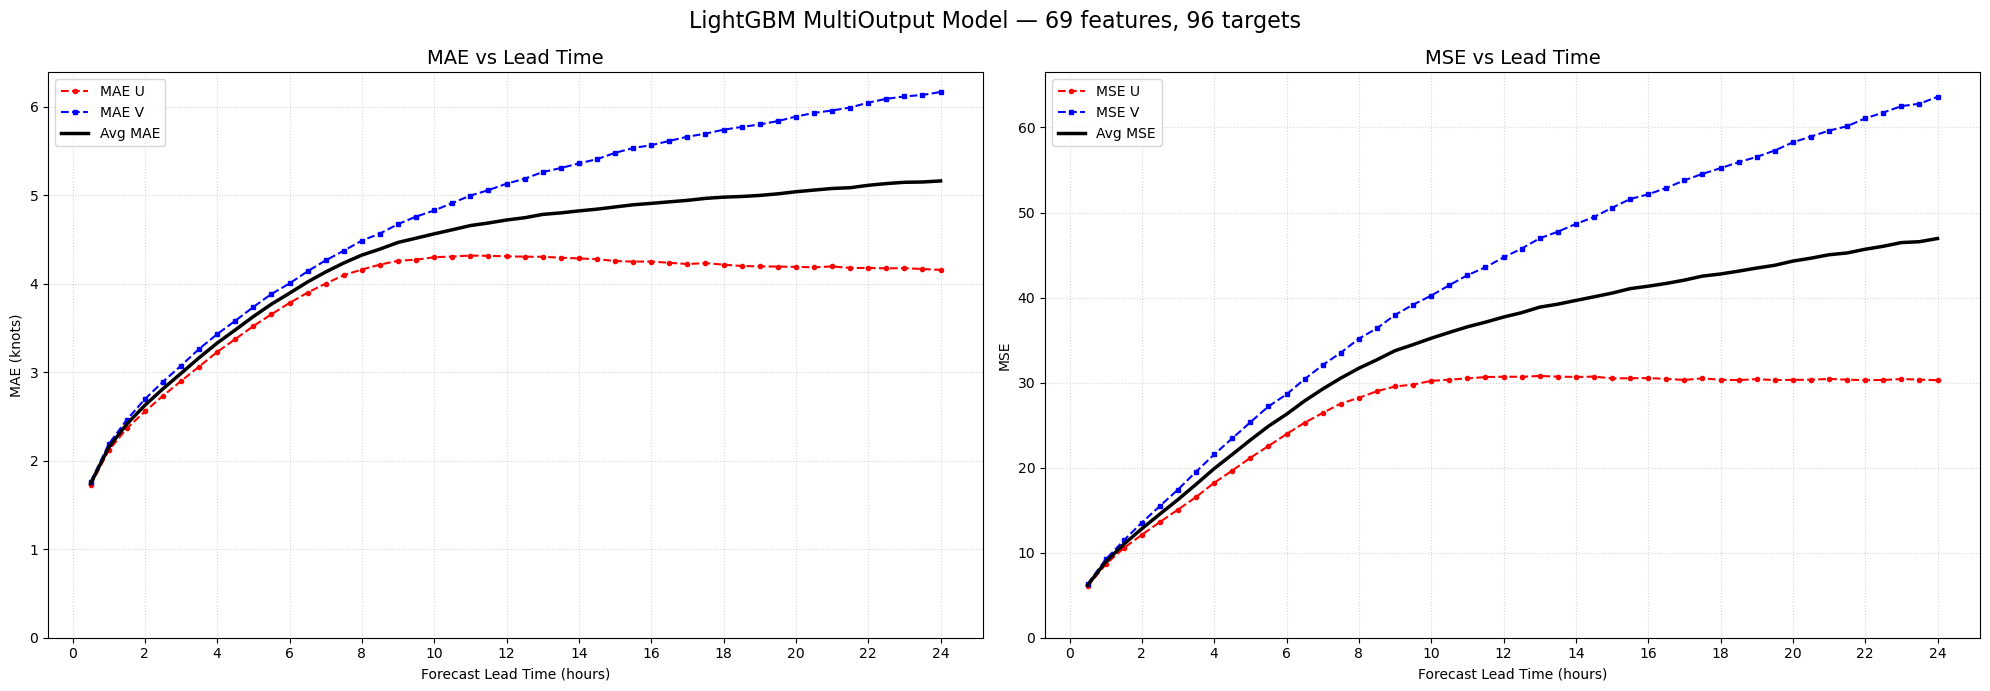

In [20]:
# --- Model Performance vs Forecast Lead Time ---

fig, (ax_mae, ax_mse) = plt.subplots(1, 2, figsize=(20, 7))

hours = metrics_df['hours']

ax_mae.plot(hours, metrics_df['MAE_u'], 'r--o', markersize=3, label='MAE U')
ax_mae.plot(hours, metrics_df['MAE_v'], 'b--s', markersize=3, label='MAE V')
ax_mae.plot(hours, metrics_df['Avg_MAE'], 'k-', linewidth=2.5, label='Avg MAE')
ax_mae.set_xlabel('Forecast Lead Time (hours)')
ax_mae.set_ylabel('MAE (knots)')
ax_mae.set_xticks(np.arange(0, 26, 2))
ax_mae.set_ylim(bottom=0)
ax_mae.grid(True, ls=':', alpha=0.5)
ax_mae.set_title('MAE vs Lead Time', fontsize=14)
ax_mae.legend()

ax_mse.plot(hours, metrics_df['MSE_u'], 'r--o', markersize=3, label='MSE U')
ax_mse.plot(hours, metrics_df['MSE_v'], 'b--s', markersize=3, label='MSE V')
ax_mse.plot(hours, metrics_df['Avg_MSE'], 'k-', linewidth=2.5, label='Avg MSE')
ax_mse.set_xlabel('Forecast Lead Time (hours)')
ax_mse.set_ylabel('MSE')
ax_mse.set_xticks(np.arange(0, 26, 2))
ax_mse.set_ylim(bottom=0)
ax_mse.grid(True, ls=':', alpha=0.5)
ax_mse.set_title('MSE vs Lead Time', fontsize=14)
ax_mse.legend()

fig.suptitle(f'LightGBM MultiOutput Model — {len(feature_cols)} features, {len(target_cols)} targets', fontsize=16)
plt.tight_layout()
plt.show()